In [5]:
import pandas as pd

column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

# Load the dataset
df = pd.read_csv('iris.data', header=None, names=column_names)









Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


In [6]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [7]:
# View data types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [8]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


In [9]:
df_cleaned = df.dropna()


In [11]:
# Basic statistics
print(df.describe())

# Median (not included in .describe())
print("\nMedian values:")
print(df.median(numeric_only=True))


       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Median values:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64


In [12]:
grouped_means = df.groupby('class').mean(numeric_only=True)
print("\nMean values grouped by species:")
print(grouped_means)



Mean values grouped by species:
                 sepal_length  sepal_width  petal_length  petal_width
class                                                                
Iris-setosa             5.006        3.418         1.464        0.244
Iris-versicolor         5.936        2.770         4.260        1.326
Iris-virginica          6.588        2.974         5.552        2.026


In [13]:
# Setosa has significantly smaller petal length and width than the other species.

# Virginica tends to have larger values for most features.

# Versicolor usually sits between Setosa and Virginica in terms of measurements.

# Sepal dimensions vary less than petal dimensions across species—petals are more distinctive for classification.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Set plot style
sns.set(style="whitegrid")

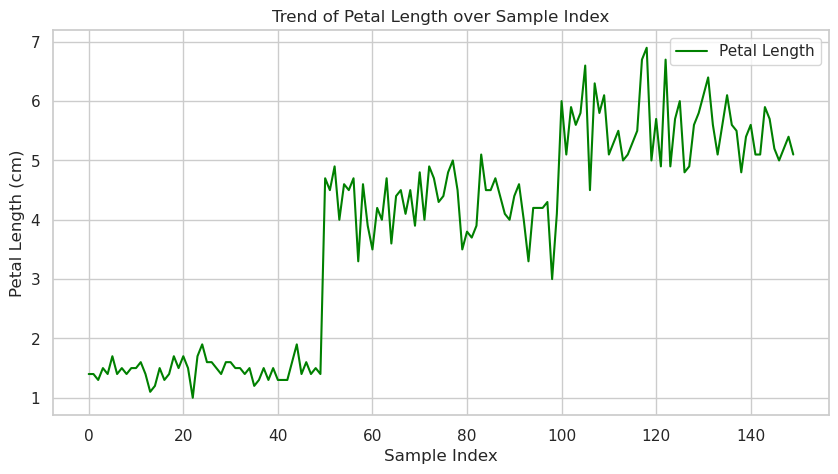

In [16]:
# 1. Line Chart - Simulated "time" trend of petal length
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['petal_length'], label='Petal Length', color='green')
plt.title('Trend of Petal Length over Sample Index')
plt.xlabel('Sample Index')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.show()

/tmp/ipykernel_227/2634372676.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='class', y='petal_length', data=df, ci=None, palette="viridis")


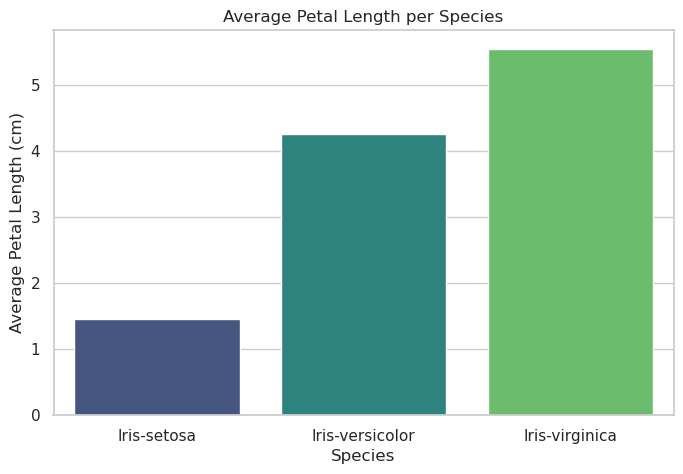

In [17]:
# 2. Bar Chart - Average petal length per species
plt.figure(figsize=(8, 5))
sns.barplot(x='class', y='petal_length', data=df, ci=None, palette="viridis")
plt.title('Average Petal Length per Species')
plt.xlabel('Species')
plt.ylabel('Average Petal Length (cm)')
plt.show()

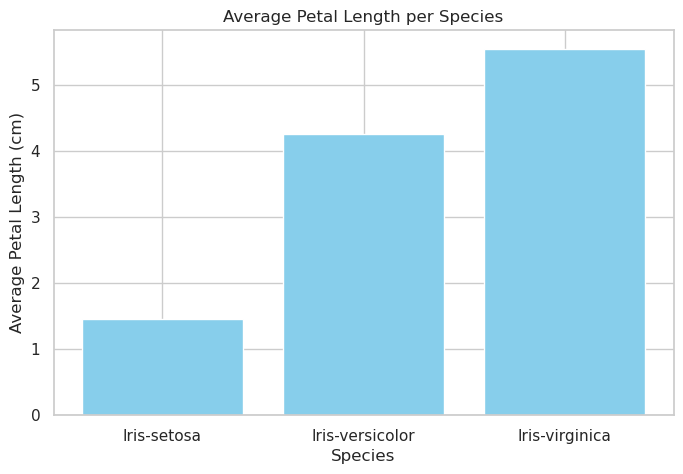

In [18]:
# Sample grouped data
means = df.groupby('class')['petal_length'].mean()

# Use plt.bar() — you must pass categories and their means explicitly
plt.figure(figsize=(8, 5))
plt.bar(means.index, means.values, color='skyblue')
plt.title('Average Petal Length per Species')
plt.xlabel('Species')
plt.ylabel('Average Petal Length (cm)')
plt.show()

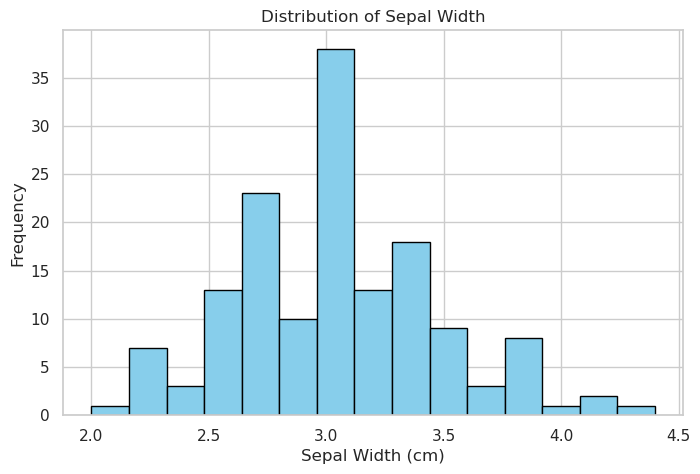

In [19]:
# 3. Histogram - Distribution of Sepal Width
plt.figure(figsize=(8, 5))
plt.hist(df['sepal_width'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Sepal Width')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.show()


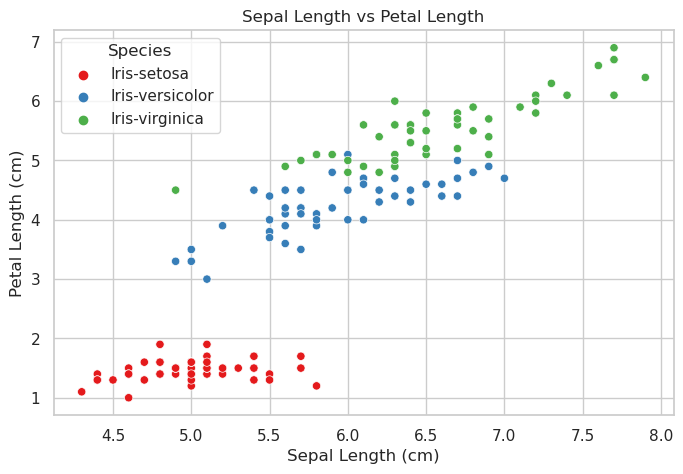

In [20]:
# 4. Scatter Plot - Sepal Length vs. Petal Length colored by species
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='petal_length', hue='class', palette='Set1')
plt.title('Sepal Length vs Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')
plt.show()